# OECD Well-being Data Analysis
## Social Capital and Subjective Well-being
### Evidence from the OECD Well-being Data Monitor

---
**Dataset:** OECD Well-being Data Monitor — Current Well-being (DSD_HSL@DF_HSL_CWB)  
**Primary RQ:** Is social capital, operationalised through social support and personal safety, meaningfully associated with subjective well-being in countries covered by the OECD Well-being dataset, and is this association threatened by long working hours?


---
# STEP 0 — Setup
## 0.1 Install and Import Libraries

In [1]:
# ── Core libraries
import pandas as pd
import numpy as np
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# ── Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# ── Statistics
from scipy import stats
import pingouin as pg
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.utils import resample

# ── Plot style
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3
})
sns.set_palette('Set2')
print('✅ All libraries loaded successfully.')

from IPython.display import display

# ── Output folder for generated notebook figures/files
FIGURE_DIR = Path('figures_notebook_outputs')
FIGURE_DIR.mkdir(exist_ok=True)
print(f'📁 Notebook figures will be saved in: {FIGURE_DIR.resolve()}')


✅ All libraries loaded successfully.
📁 Notebook figures will be saved in: /Users/shakhawat/Documents/Codex/DS Lab/figures_notebook_outputs


---
# STEP 1 — Data Loading & Overview
## 1.1 Load Raw Dataset

In [2]:

# ── Show full columns & better width
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

# ── Load the dataset
FILE_PATH = "OECD.WISE.WDP,DSD_HSL@DF_HSL_CWB,1.1+all.csv"
df_raw = pd.read_csv(FILE_PATH)

# ── Basic info
print("Shape:", df_raw.shape)
print("Columns:", df_raw.columns.tolist())

# ── Display with horizontal scroll (best view)
display(df_raw.head(3))

Shape: (110277, 30)
Columns: ['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'ACTION', 'REF_AREA', 'Reference area', 'MEASURE', 'Measure', 'UNIT_MEASURE', 'Unit of measure', 'AGE', 'Age', 'SEX', 'Sex', 'EDUCATION_LEV', 'Education level', 'DOMAIN', 'Domain', 'TIME_PERIOD', 'Time period', 'OBS_VALUE', 'Observation value', 'OBS_STATUS', 'Observation status', 'UNIT_MULT', 'Unit multiplier', 'DECIMALS', 'Decimals', 'BASE_PER', 'Base period']


,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,MEASURE,Measure,UNIT_MEASURE,Unit of measure,AGE,Age,SEX,Sex,EDUCATION_LEV,Education level,DOMAIN,Domain,TIME_PERIOD,Time period,OBS_VALUE,Observation value,OBS_STATUS,Observation status,UNIT_MULT,Unit multiplier,DECIMALS,Decimals,BASE_PER,Base period
0,DATAFLOW,OECD.WISE.WDP:DSD_HSL@DF_HSL_CWB(1.1),Current well-being,I,AUS,Australia,11_3,Feelings of physical pain,PT_POP_Y_GE15_SUB,Percentage of population aged 15 years or over in the same subgroup,MID,Middle-aged,_T,Total,_T,Total,HSL_11,Subjective well-being,2006,NaN,20.512882,NaN,A,Normal value,0.0,Units,2.0,Two,_Z,NaN
1,DATAFLOW,OECD.WISE.WDP:DSD_HSL@DF_HSL_CWB(1.1),Current well-being,I,AUS,Australia,11_3,Feelings of physical pain,PT_POP_Y_GE15_SUB,Percentage of population aged 15 years or over in the same subgroup,MID,Middle-aged,_T,Total,_T,Total,HSL_11,Subjective well-being,2007,NaN,20.512882,NaN,A,Normal value,0.0,Units,2.0,Two,_Z,NaN
2,DATAFLOW,OECD.WISE.WDP:DSD_HSL@DF_HSL_CWB(1.1),Current well-being,I,AUS,Australia,11_3,Feelings of physical pain,PT_POP_Y_GE15_SUB,Percentage of population aged 15 years or over in the same subgroup,MID,Middle-aged,_T,Total,_T,Total,HSL_11,Subjective well-being,2008,NaN,20.512882,NaN,A,Normal value,0.0,Units,2.0,Two,_Z,NaN


## 1.2 Dataset Overview — Dimensions

In [3]:
print('=== DATASET OVERVIEW ===')
print(f"Total rows:                {len(df_raw):,}")
print(f"Total columns:             {df_raw.shape[1]}")
print(f"Countries/Reference Area:  {df_raw['Reference area'].nunique()}")
print(f"Domains:                   {df_raw['Domain'].nunique()}")
print(f"Measures:                  {df_raw['Measure'].nunique()}")
print(f"Year range:                {df_raw['TIME_PERIOD'].min()} – {df_raw['TIME_PERIOD'].max()}")
print()
print('--- Domains ---')
for d in sorted(df_raw['Domain'].unique()):
    n = df_raw[df_raw['Domain']==d]['Measure'].nunique()
    print(f'  {d} ({n} measures)')

=== DATASET OVERVIEW ===
Total rows:                110,277
Total columns:             30
Countries/Reference Area:  47
Domains:                   11
Measures:                  68
Year range:                2004 – 2026

--- Domains ---
  Civic engagement (3 measures)
  Environmental quality (3 measures)
  Health (5 measures)
  Housing (5 measures)
  Income and wealth (7 measures)
  Knowledge and skills (12 measures)
  Safety (4 measures)
  Social connections (7 measures)
  Subjective well-being (5 measures)
  Work and job quality (11 measures)
  Work-life balance (6 measures)


## 1.3 Key Variables — Availability Check

In [4]:
KEY_VARS = [
    'Social support',
    'Life satisfaction',
    'Not feeling safe at night',
    'Negative affect balance',
    'Long hours in paid work',
]

print(f'{"Variable":<30} {"Countries":>10} {"Years":>8} {"Non-null":>10} {"Sex":>5} {"Age":>5}')
print('-' * 75)
for var in KEY_VARS:
    s = df_raw[df_raw['Measure'] == var]
    n_countries = s['Reference area'].nunique()
    n_years = s['TIME_PERIOD'].nunique()
    n_values = s['OBS_VALUE'].notna().sum()
    has_sex = '✅' if 'Male' in s['Sex'].values else '❌'
    has_age = '✅' if 'Young' in s['Age'].values else '❌'
    print(f'{var:<30} {n_countries:>10} {n_years:>8} {n_values:>10} {has_sex:>5} {has_age:>5}')

Variable                        Countries    Years   Non-null   Sex   Age
---------------------------------------------------------------------------
Social support                         47       20       7424     ✅     ✅
Life satisfaction                      37       17       2055     ✅     ✅
Not feeling safe at night              47       20       7417     ✅     ✅
Negative affect balance                47       20       7416     ✅     ✅
Long hours in paid work                43       21       5149     ✅     ✅


---
# STEP 2 — Data Cleaning & Preprocessing
## 2.1 Select and Rename Relevant Columns

In [5]:
# Keep only the columns we need
KEEP_COLS = {
    'Reference area': 'country',
    'Measure':        'measure',
    'Domain':         'domain',
    'Sex':            'sex',
    'Age':            'age',
    'Education level':'education',
    'TIME_PERIOD':    'year',
    'OBS_VALUE':      'value'
}

df = df_raw[list(KEEP_COLS.keys())].rename(columns=KEEP_COLS).copy()
df = df[df['measure'].isin(KEY_VARS)]
df = df.dropna(subset=['value'])

print(f'Filtered dataset shape: {df.shape}')
df.head(5)

Filtered dataset shape: (29461, 8)


,country,measure,domain,sex,age,education,year,value
4336,Australia,Negative affect balance,Subjective well-being,Male,Total,Total,2006,10.368023
4337,Australia,Negative affect balance,Subjective well-being,Male,Total,Total,2007,10.368023
4338,Australia,Negative affect balance,Subjective well-being,Male,Total,Total,2008,9.906412
4339,Australia,Negative affect balance,Subjective well-being,Male,Total,Total,2009,9.906412
4340,Australia,Negative affect balance,Subjective well-being,Male,Total,Total,2010,9.906412


In [6]:
df.shape

(29461, 8)

## 2.2 Check Missing Values

In [7]:
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Value range per measure:')
df.groupby('measure')['value'].describe().round(3)

Missing values per column:
country      0
measure      0
domain       0
sex          0
age          0
education    0
year         0
value        0
dtype: int64

Value range per measure:


,count,mean,std,min,25%,50%,75%,max
measure,,,,,,,,
Life satisfaction,2055.0,7.233,0.725,3.788,6.900,7.407,7.731,8.700
Long hours in paid work,5149.0,8.287,9.075,0.010,2.420,5.090,10.420,63.550
Negative affect balance,7416.0,13.133,5.316,3.237,9.289,11.898,15.679,39.602
Not feeling safe at night,7417.0,30.285,15.185,2.675,18.615,26.896,39.837,81.137
Social support,7424.0,89.693,5.769,62.055,87.137,91.014,93.695,100.000


## 2.3 Build Analytical Subsets for Each RQ

In [8]:
def get_measure(measure, sex='Total', age='Total', edu='Total', year_range=None):
    """Helper: extract a clean subset for one measure."""
    mask = (
        (df['measure'] == measure) &
        (df['sex'] == sex) &
        (df['age'] == age) &
        (df['education'] == edu)
    )
    out = df[mask].copy()
    if year_range:
        out = out[(out['year'] >= year_range[0]) & (out['year'] <= year_range[1])]
    return out[['country','year','value']].rename(columns={'value': measure})

# ── RQ1 subset: Social support + Life satisfaction (Total, by Age)
rq1_total = pd.merge(
    get_measure('Social support'),
    get_measure('Life satisfaction'),
    on=['country','year'], how='inner'
)

# ── RQ2 subset: Not feeling safe + Negative affect (by Sex)
rq2_male = pd.merge(
    get_measure('Not feeling safe at night', sex='Male'),
    get_measure('Negative affect balance', sex='Male'),
    on=['country','year'], how='inner'
).assign(sex='Male')

rq2_female = pd.merge(
    get_measure('Not feeling safe at night', sex='Female'),
    get_measure('Negative affect balance', sex='Female'),
    on=['country','year'], how='inner'
).assign(sex='Female')

rq2_total = pd.concat([rq2_male, rq2_female], ignore_index=True)

# ── RQ3 subset: Long hours + Social support + Life satisfaction (by Age)
rq3_total = pd.merge(
    get_measure('Long hours in paid work'),
    get_measure('Social support'),
    on=['country','year'], how='inner'
)
rq3_total = pd.merge(rq3_total, get_measure('Life satisfaction'), on=['country','year'], how='inner')

print(f'RQ1 dataset: {rq1_total.shape} | Countries: {rq1_total["country"].nunique()}')
print(f'RQ2 dataset: {rq2_total.shape} | Countries: {rq2_total["country"].nunique()}')
print(f'RQ3 dataset: {rq3_total.shape} | Countries: {rq3_total["country"].nunique()}')

RQ1 dataset: (245, 4) | Countries: 37
RQ2 dataset: (1864, 5) | Countries: 47
RQ3 dataset: (209, 5) | Countries: 35


---
# STEP 3 — Research Question 1
## Does social support predict life satisfaction, and does this relationship differ across age groups?
---

## 3.1 Descriptive Statistics

In [9]:
rq1_total.shape

(245, 4)

In [10]:
rq1_total.head()

,country,year,Social support,Life satisfaction
0,Australia,2019,94.095001,7.500000
1,Australia,2020,92.969471,7.200000
2,Austria,2013,93.958903,7.810006
3,Austria,2018,92.101824,8.002416
4,Austria,2021,88.693065,7.991946


In [11]:
print('=== RQ1 — DESCRIPTIVE STATISTICS ===')
print()
print('Social Support:')
print(rq1_total['Social support'].describe().round(3))
print()
print('Life Satisfaction:')
print(rq1_total['Life satisfaction'].describe().round(3))

=== RQ1 — DESCRIPTIVE STATISTICS ===

Social Support:
count    245.000
mean      89.723
std        4.979
min       73.302
25%       87.861
50%       91.049
75%       93.147
max       97.023
Name: Social support, dtype: float64

Life Satisfaction:
count    245.000
mean       7.215
std        0.685
min        4.771
25%        6.951
50%        7.378
75%        7.696
max        8.449
Name: Life satisfaction, dtype: float64


## 3.2 Exploratory Data Analysis (EDA)
### 3.2a Distribution Plots

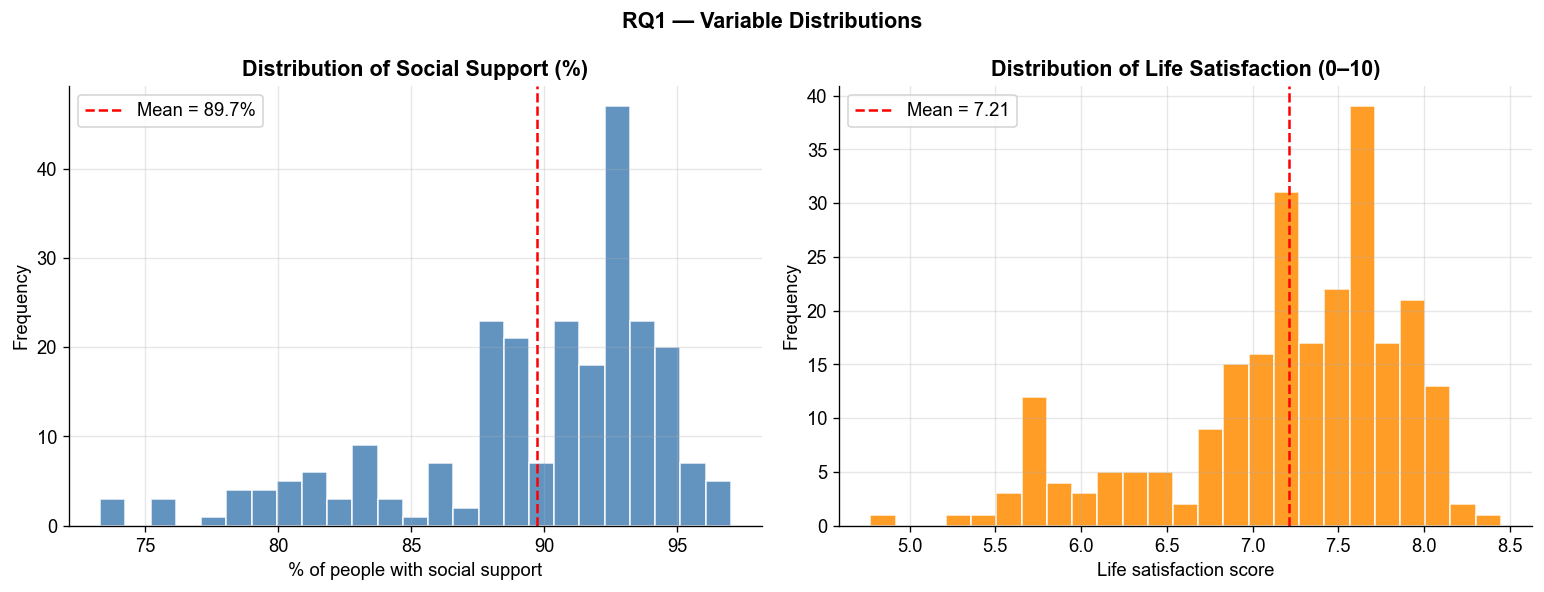

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(rq1_total['Social support'].dropna(), bins=25, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(rq1_total['Social support'].mean(), color='red', linestyle='--', label=f'Mean = {rq1_total["Social support"].mean():.1f}%')
axes[0].set_title('Distribution of Social Support (%)')
axes[0].set_xlabel('% of people with social support')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(rq1_total['Life satisfaction'].dropna(), bins=25, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].axvline(rq1_total['Life satisfaction'].mean(), color='red', linestyle='--', label=f'Mean = {rq1_total["Life satisfaction"].mean():.2f}')
axes[1].set_title('Distribution of Life Satisfaction (0–10)')
axes[1].set_xlabel('Life satisfaction score')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('RQ1 — Variable Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'rq1_distributions.png', bbox_inches='tight')
plt.show()

### 3.2b Time Trend — Social Support in Countries Covered by the OECD Dataset

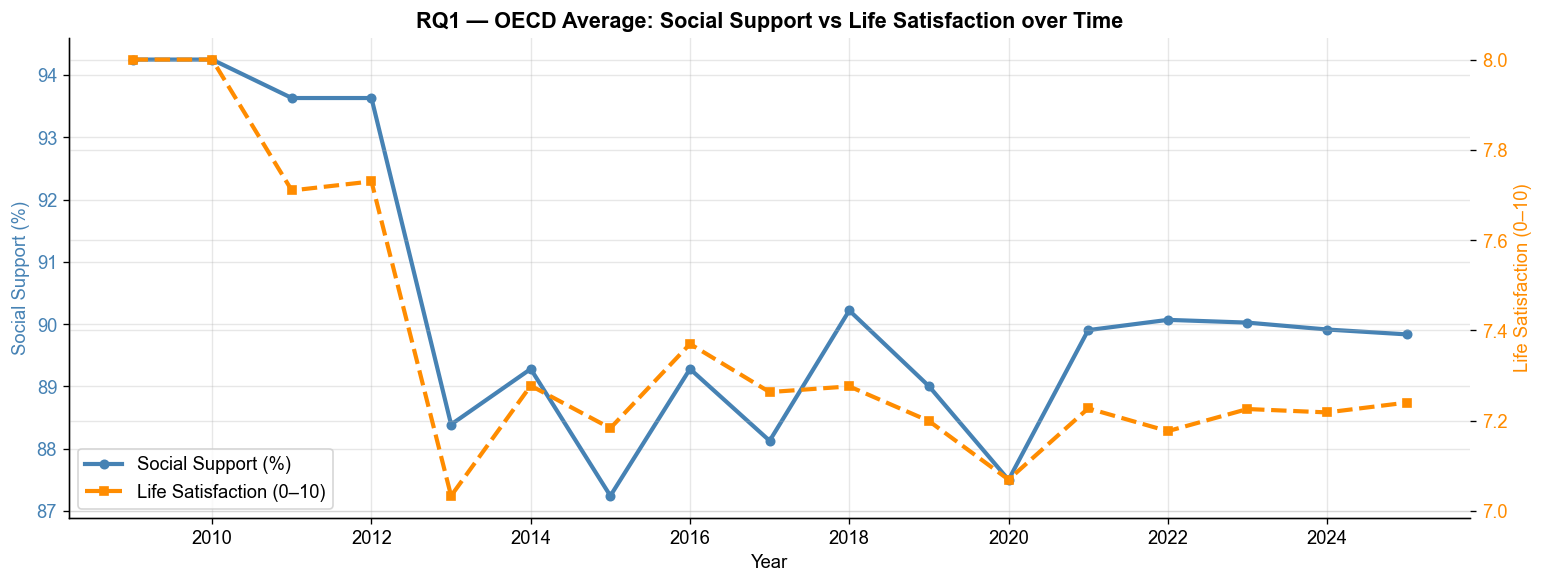

In [13]:
trend = rq1_total.groupby('year')[['Social support','Life satisfaction']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.plot(trend['year'], trend['Social support'], color='steelblue', lw=2.5, marker='o', ms=5, label='Social Support (%)')
ax2.plot(trend['year'], trend['Life satisfaction'], color='darkorange', lw=2.5, marker='s', ms=5, linestyle='--', label='Life Satisfaction (0–10)')

ax1.set_xlabel('Year')
ax1.set_ylabel('Social Support (%)', color='steelblue')
ax2.set_ylabel('Life Satisfaction (0–10)', color='darkorange')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='darkorange')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='lower left')

plt.title('RQ1 — OECD Average: Social Support vs Life Satisfaction over Time', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'rq1_time_trend.png', bbox_inches='tight')
plt.show()

### 3.2c Country-level Scatter Plot

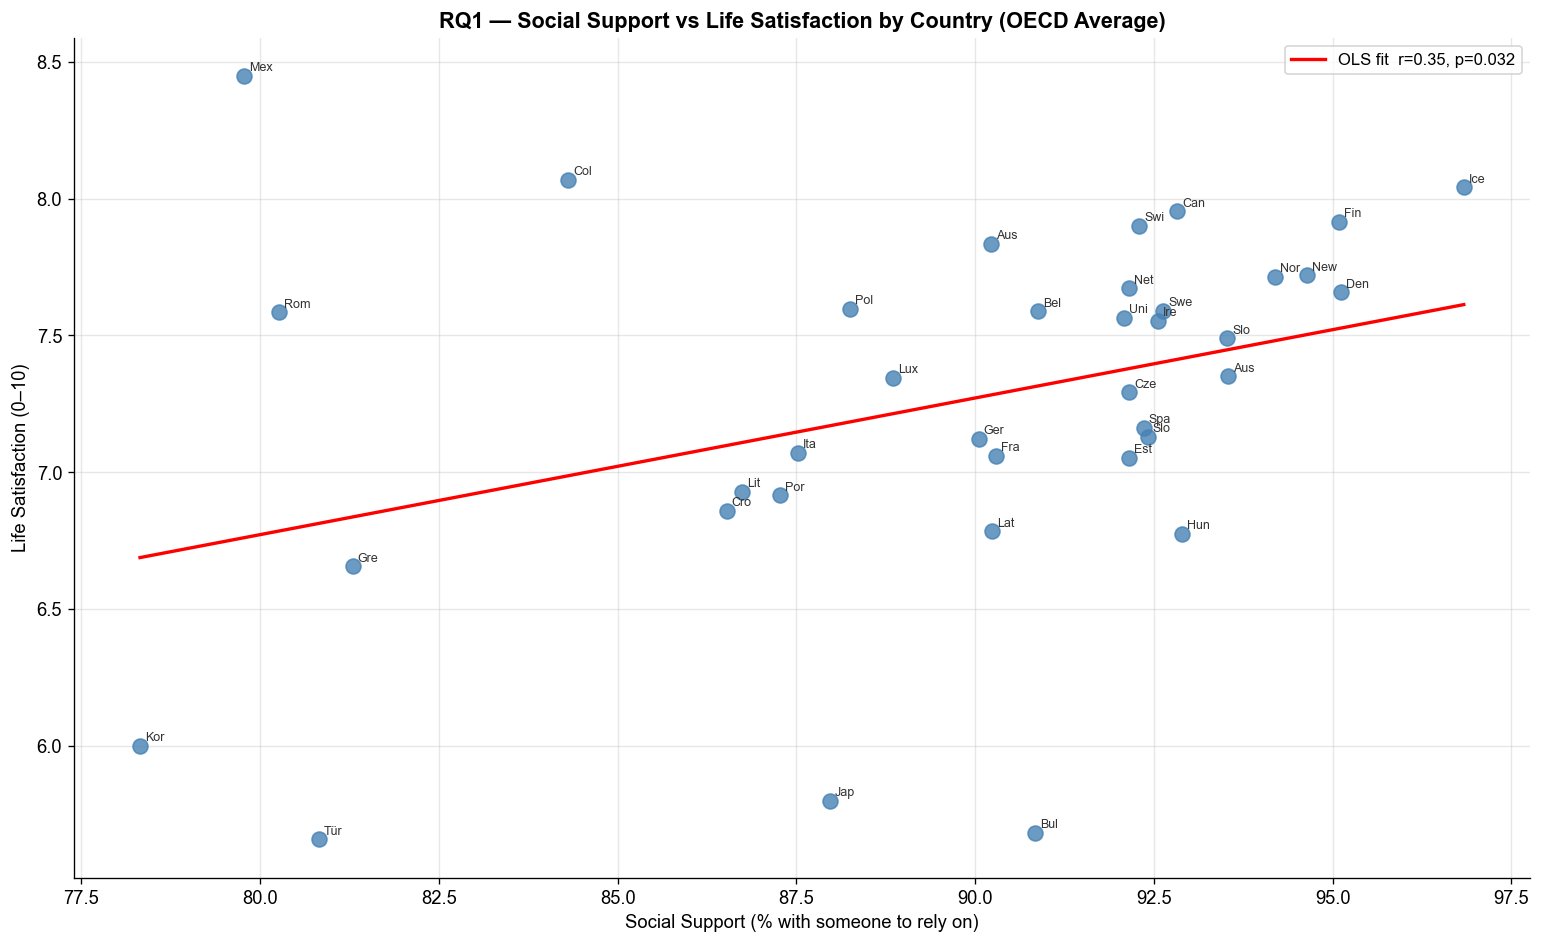

Country-average Pearson r = 0.354, p-value = 0.0316
Interpretation: Moderate correlation


In [14]:
# Average across all years per country
rq1_country = rq1_total.groupby('country')[['Social support','Life satisfaction']].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 8))
ax.scatter(rq1_country['Social support'], rq1_country['Life satisfaction'],
           color='steelblue', s=80, alpha=0.8, zorder=3)

# Regression line and country-average correlation
m_country, b_country, rq1_country_r, rq1_country_p, rq1_country_se = stats.linregress(
    rq1_country['Social support'],
    rq1_country['Life satisfaction']
)
x_line = np.linspace(rq1_country['Social support'].min(), rq1_country['Social support'].max(), 100)
ax.plot(
    x_line,
    m_country*x_line + b_country,
    color='red', lw=2,
    label=f'OLS fit  r={rq1_country_r:.2f}, p={rq1_country_p:.3f}'
)

# Country labels
for _, row in rq1_country.iterrows():
    ax.annotate(row['country'][:3], (row['Social support'], row['Life satisfaction']),
                fontsize=7.5, color='#333333', xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('Social Support (% with someone to rely on)', fontsize=11)
ax.set_ylabel('Life Satisfaction (0–10)', fontsize=11)
ax.set_title('RQ1 — Social Support vs Life Satisfaction by Country (OECD Average)', fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'rq1_scatter.png', bbox_inches='tight')
plt.show()

print(f'Country-average Pearson r = {rq1_country_r:.3f}, p-value = {rq1_country_p:.4f}')
print(f'Interpretation: {"Strong" if abs(rq1_country_r)>0.6 else "Moderate" if abs(rq1_country_r)>0.3 else "Weak"} correlation')


## 3.3 Correlation Analysis
### 3.3a Pearson Correlation

In [15]:
rq1_pearson_r, rq1_pearson_p = stats.pearsonr(
    rq1_total['Social support'].dropna(),
    rq1_total['Life satisfaction'].dropna()
)
print(f'Pearson Correlation (Social Support vs Life Satisfaction):')
print(f'  r = {rq1_pearson_r:.4f}')
print(f'  p = {rq1_pearson_p:.4f}')
print(f'  Significant at 5%: {"Yes" if rq1_pearson_p < 0.05 else "No"}')


Pearson Correlation (Social Support vs Life Satisfaction):
  r = 0.5165
  p = 0.0000
  Significant at 5%: Yes


### 3.3b Partial Correlation (controlling for year)

In [16]:
rq1_clean = rq1_total.dropna(subset=['Social support','Life satisfaction','year']).copy()
rq1_partial = pg.partial_corr(
    data=rq1_clean,
    x='Social support',
    y='Life satisfaction',
    covar='year'
)
rq1_partial_r = rq1_partial['r'].iloc[0]
rq1_partial_p = rq1_partial['p_val'].iloc[0]
print('Partial Correlation (controlling for year):')
print(rq1_partial.round(4))


Partial Correlation (controlling for year):
           n       r         CI95  p_val
pearson  245  0.5169  [0.42, 0.6]    0.0


## 3.4 OLS Regression
### 3.4a Model Fit

In [17]:
rq1_clean = rq1_total.dropna(subset=['Social support','Life satisfaction']).copy()
rq1_clean.columns = [c.replace(' ','_') for c in rq1_clean.columns]

model_rq1 = smf.ols('Life_satisfaction ~ Social_support + year', data=rq1_clean).fit()
print(model_rq1.summary())

                            OLS Regression Results                            
Dep. Variable:      Life_satisfaction   R-squared:                       0.267
Model:                            OLS   Adj. R-squared:                  0.261
Method:                 Least Squares   F-statistic:                     44.11
Date:                Fri, 05 Jun 2026   Prob (F-statistic):           4.62e-17
Time:                        23:49:06   Log-Likelihood:                -216.49
No. Observations:                 245   AIC:                             439.0
Df Residuals:                     242   BIC:                             449.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          7.6952     18.967      0.

### 3.4b Predicted vs Actual Plot

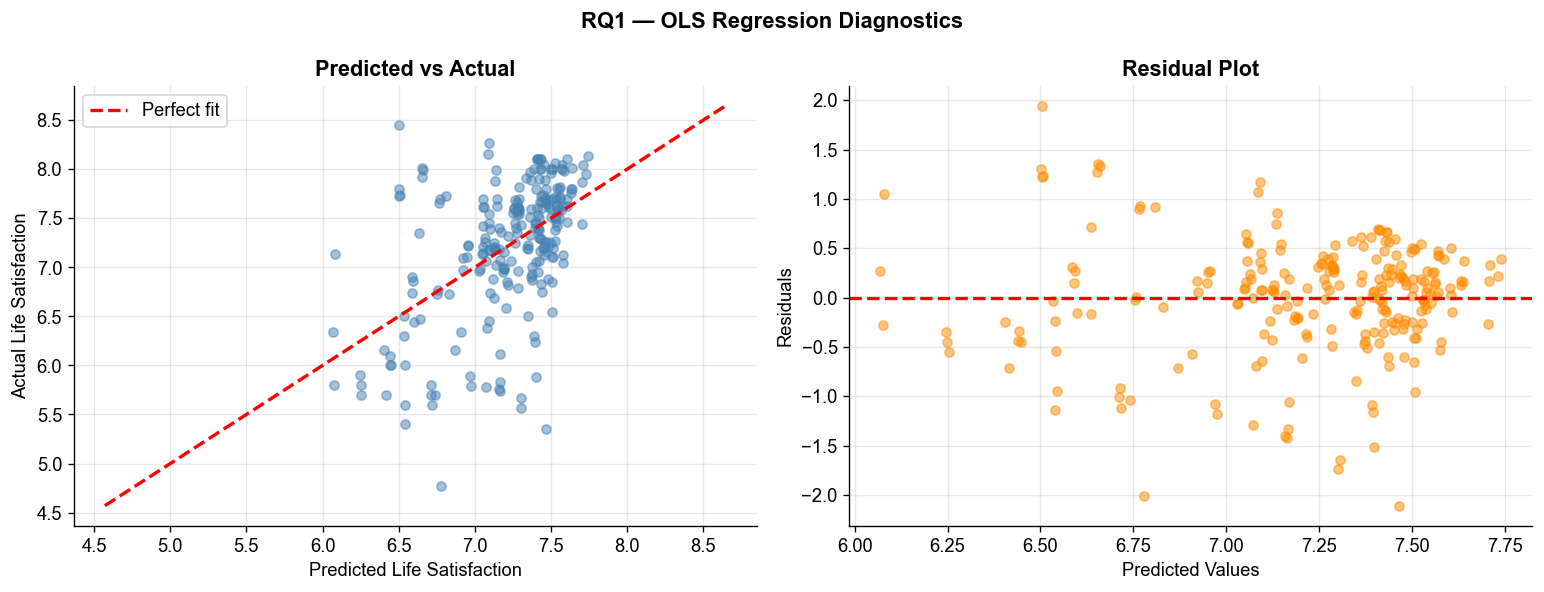

R² = 0.2672
Adj. R² = 0.2611


In [18]:
rq1_clean['predicted'] = model_rq1.fittedvalues
rq1_clean['residuals'] = model_rq1.resid

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs Actual
axes[0].scatter(rq1_clean['predicted'], rq1_clean['Life_satisfaction'], alpha=0.5, color='steelblue', s=30)
lim = [min(rq1_clean['predicted'].min(), rq1_clean['Life_satisfaction'].min()) - 0.2,
       max(rq1_clean['predicted'].max(), rq1_clean['Life_satisfaction'].max()) + 0.2]
axes[0].plot(lim, lim, 'r--', lw=2, label='Perfect fit')
axes[0].set_xlabel('Predicted Life Satisfaction')
axes[0].set_ylabel('Actual Life Satisfaction')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()

# Residuals
axes[1].scatter(rq1_clean['predicted'], rq1_clean['residuals'], alpha=0.5, color='darkorange', s=30)
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

plt.suptitle('RQ1 — OLS Regression Diagnostics', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'rq1_regression.png', bbox_inches='tight')
plt.show()

print(f'R² = {model_rq1.rsquared:.4f}')
print(f'Adj. R² = {model_rq1.rsquared_adj:.4f}')

## 3.5 Bootstrap Confidence Intervals

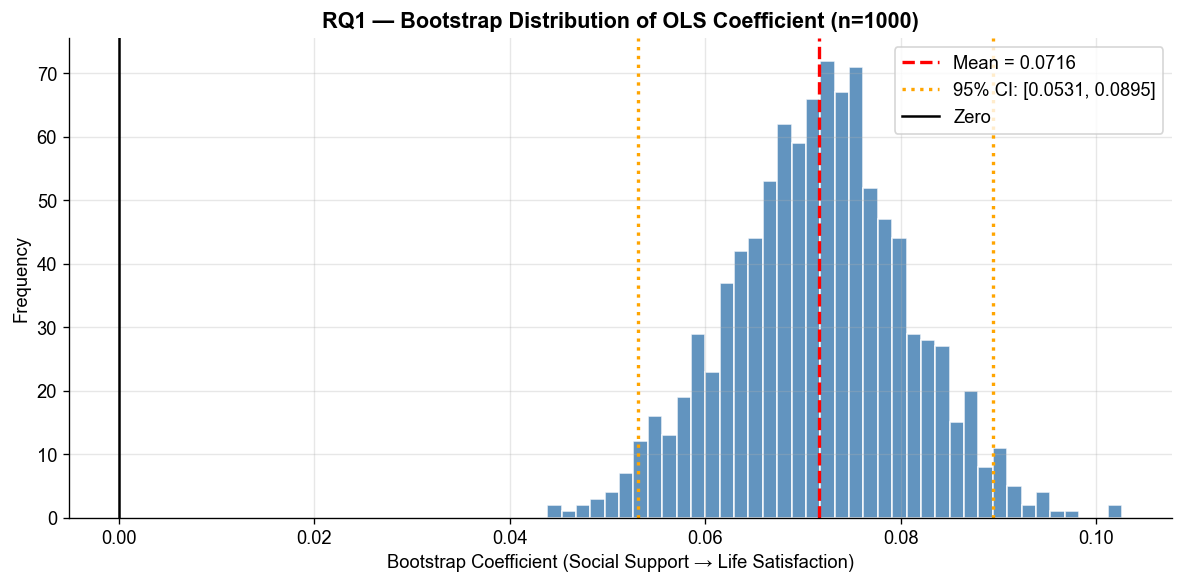

Bootstrap Mean Coefficient: 0.0716
95% Bootstrap CI: [0.0531, 0.0895]
Zero inside CI? No → Significant


In [19]:
np.random.seed(42)
n_boot = 1000
boot_coefs = []

for _ in range(n_boot):
    sample = resample(rq1_clean)
    try:
        m = smf.ols('Life_satisfaction ~ Social_support + year', data=sample).fit()
        boot_coefs.append(m.params['Social_support'])
    except:
        pass

boot_coefs = np.array(boot_coefs)
ci_low, ci_high = np.percentile(boot_coefs, [2.5, 97.5])

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(boot_coefs, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(boot_coefs.mean(), color='red', lw=2, linestyle='--', label=f'Mean = {boot_coefs.mean():.4f}')
ax.axvline(ci_low, color='orange', lw=2, linestyle=':', label=f'95% CI: [{ci_low:.4f}, {ci_high:.4f}]')
ax.axvline(ci_high, color='orange', lw=2, linestyle=':')
ax.axvline(0, color='black', lw=1.5, label='Zero')
ax.set_xlabel('Bootstrap Coefficient (Social Support → Life Satisfaction)')
ax.set_ylabel('Frequency')
ax.set_title('RQ1 — Bootstrap Distribution of OLS Coefficient (n=1000)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'rq1_bootstrap.png', bbox_inches='tight')
plt.show()

print(f'Bootstrap Mean Coefficient: {boot_coefs.mean():.4f}')
print(f'95% Bootstrap CI: [{ci_low:.4f}, {ci_high:.4f}]')
print(f'Zero inside CI? {"No → Significant" if not (ci_low <= 0 <= ci_high) else "Yes → Not significant"}')

## 3.6 Age Group Comparison — Young vs Old

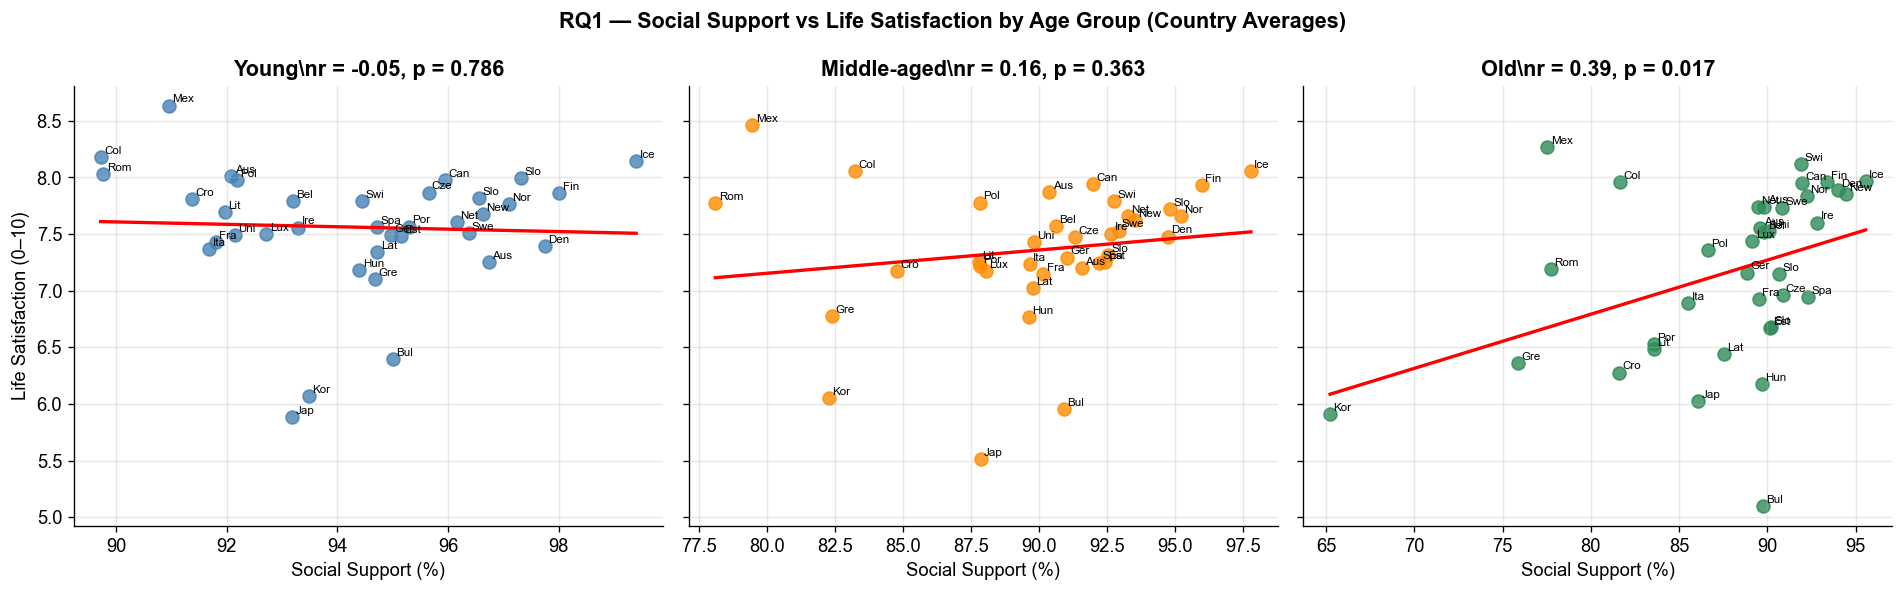

Country-average age-group correlations:
Young: countries=36, r=-0.047, p=0.7855
Middle-aged: countries=36, r=0.156, p=0.3629
Old: countries=36, r=0.395, p=0.0172


In [20]:
# Build age-specific subsets
age_groups = ['Young', 'Middle-aged', 'Old']
colors = {'Young': 'steelblue', 'Middle-aged': 'darkorange', 'Old': 'seagreen'}

age_dfs = {}
rq1_age_country_avg_corrs = {}

for age in age_groups:
    merged = pd.merge(
        get_measure('Social support', age=age),
        get_measure('Life satisfaction', age=age),
        on=['country','year'], how='inner'
    )
    age_dfs[age] = merged

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for i, age in enumerate(age_groups):
    data = age_dfs[age].dropna()
    country_avg = data.groupby('country')[['Social support','Life satisfaction']].mean().reset_index()
    axes[i].scatter(country_avg['Social support'], country_avg['Life satisfaction'],
                    color=colors[age], s=60, alpha=0.8)
    if len(country_avg) > 2:
        m_age, b_age, age_country_r, age_country_p, _ = stats.linregress(
            country_avg['Social support'],
            country_avg['Life satisfaction']
        )
        rq1_age_country_avg_corrs[age] = {
            'n_country_year': len(data),
            'countries': country_avg['country'].nunique(),
            'r': age_country_r,
            'p': age_country_p
        }
        x_l = np.linspace(country_avg['Social support'].min(), country_avg['Social support'].max(), 100)
        axes[i].plot(x_l, m_age*x_l+b_age, color='red', lw=2)
        title_text = f'{age}' + '\\n' + f'r = {age_country_r:.2f}, p = {age_country_p:.3f}'
        axes[i].set_title(title_text, fontweight='bold')
    for _, row in country_avg.iterrows():
        axes[i].annotate(row['country'][:3], (row['Social support'], row['Life satisfaction']),
                         fontsize=7, xytext=(2, 2), textcoords='offset points')
    axes[i].set_xlabel('Social Support (%)')
    if i == 0:
        axes[i].set_ylabel('Life Satisfaction (0–10)')

plt.suptitle('RQ1 — Social Support vs Life Satisfaction by Age Group (Country Averages)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'rq1_age_groups.png', bbox_inches='tight')
plt.show()

print('Country-average age-group correlations:')
for age, vals in rq1_age_country_avg_corrs.items():
    print(f'{age}: countries={vals["countries"]}, r={vals["r"]:.3f}, p={vals["p"]:.4f}')


### 3.6b RQ1 Age Group Correlations at Country-Year Level

The previous figure uses country averages for visual comparison. The following cell tests the age-group relationship at the matched country-year level, which is the appropriate evidence to report when discussing age heterogeneity in RQ1.


In [21]:
rq1_age_corr_rows = []

for age in ['Young', 'Middle-aged', 'Old']:
    age_data = pd.merge(
        get_measure('Social support', age=age),
        get_measure('Life satisfaction', age=age),
        on=['country', 'year'],
        how='inner'
    ).dropna()

    age_r, age_p = stats.pearsonr(
        age_data['Social support'],
        age_data['Life satisfaction']
    )

    rq1_age_corr_rows.append({
        'Age group': age,
        'Observations': len(age_data),
        'Countries': age_data['country'].nunique(),
        'Years': f"{age_data['year'].min()}–{age_data['year'].max()}",
        'Pearson r': age_r,
        'p-value': age_p,
        'Significant at 5%': 'Yes' if age_p < 0.05 else 'No'
    })

rq1_age_corr_table = pd.DataFrame(rq1_age_corr_rows)
rq1_age_corr_table_display = rq1_age_corr_table.copy()
rq1_age_corr_table_display['Pearson r'] = rq1_age_corr_table_display['Pearson r'].round(3)
rq1_age_corr_table_display['p-value'] = rq1_age_corr_table_display['p-value'].map(lambda x: '<0.001' if x < 0.001 else f'{x:.4f}')

display(rq1_age_corr_table_display)

print('Interpretation:')
print('- Young: weak and not statistically significant association.')
print('- Middle-aged: moderate positive and statistically significant association.')
print('- Old: strongest positive and statistically significant association.')


,Age group,Observations,Countries,Years,Pearson r,p-value,Significant at 5%
0,Young,206,36,2009–2024,0.109,0.1202,No
1,Middle-aged,206,36,2009–2024,0.357,<0.001,Yes
2,Old,206,36,2009–2024,0.526,<0.001,Yes


Interpretation:
- Young: weak and not statistically significant association.
- Middle-aged: moderate positive and statistically significant association.
- Old: strongest positive and statistically significant association.


## 3.7 RQ1 — Key Findings Summary

In [22]:
print('=' * 60)
print('RQ1 KEY FINDINGS')
print('=' * 60)
print(f'1. Main country-year Pearson r = {rq1_pearson_r:.3f}')
print('   → Social support is positively correlated with life satisfaction.')
print(f'2. Partial correlation controlling for year = {rq1_partial_r:.3f}')
print('   → The association remains after accounting for year.')
print(f'3. OLS coefficient = {model_rq1.params["Social_support"]:.4f}')
print(f'   R² = {model_rq1.rsquared:.3f}')
print(f'4. Bootstrap 95% CI = [{ci_low:.4f}, {ci_high:.4f}]')
print('   → The confidence interval excludes zero.')
print('5. Age group comparison at country-year level:')
for _, row in rq1_age_corr_table.iterrows():
    sig = 'significant' if row['p-value'] < 0.05 else 'not significant'
    print(f'   {row["Age group"]}: r={row["Pearson r"]:.3f}, p={row["p-value"]:.4f} ({sig})')
print('=' * 60)


RQ1 KEY FINDINGS
1. Main country-year Pearson r = 0.517
   → Social support is positively correlated with life satisfaction.
2. Partial correlation controlling for year = 0.517
   → The association remains after accounting for year.
3. OLS coefficient = 0.0712
   R² = 0.267
4. Bootstrap 95% CI = [0.0531, 0.0895]
   → The confidence interval excludes zero.
5. Age group comparison at country-year level:
   Young: r=0.109, p=0.1202 (not significant)
   Middle-aged: r=0.357, p=0.0000 (significant)
   Old: r=0.526, p=0.0000 (significant)


---
# STEP 4 — Research Question 2
## Does lack of personal safety predict higher negative affect, and is this effect stronger for women than men?
---

## 4.1 Descriptive Statistics by Gender

In [23]:
rq2_total.shape

(1864, 5)

In [24]:
rq2_total.head()

,country,year,Not feeling safe at night,Negative affect balance,sex
0,Australia,2008,20.719546,9.906412,Male
1,Australia,2009,20.719546,9.906412,Male
2,Australia,2010,20.719546,9.906412,Male
3,Australia,2011,19.754920,9.153426,Male
4,Australia,2012,19.754920,9.153426,Male


In [25]:
print('=== RQ2 — DESCRIPTIVE STATISTICS BY GENDER ===')
print()
for sex in ['Male', 'Female']:
    s = rq2_total[rq2_total['sex'] == sex]
    print(f'--- {sex} ---')
    print(f'  Not feeling safe:   mean={s["Not feeling safe at night"].mean():.2f},  std={s["Not feeling safe at night"].std():.2f}')
    print(f'  Negative affect:    mean={s["Negative affect balance"].mean():.2f},  std={s["Negative affect balance"].std():.2f}')
    print(f'  Countries: {s["country"].nunique()},  Observations: {len(s)}')
    print()

=== RQ2 — DESCRIPTIVE STATISTICS BY GENDER ===

--- Male ---
  Not feeling safe:   mean=22.83,  std=14.61
  Negative affect:    mean=12.00,  std=4.74
  Countries: 47,  Observations: 932

--- Female ---
  Not feeling safe:   mean=37.78,  std=14.57
  Negative affect:    mean=15.27,  std=5.76
  Countries: 47,  Observations: 932



## 4.2 EDA — Boxplot by Gender

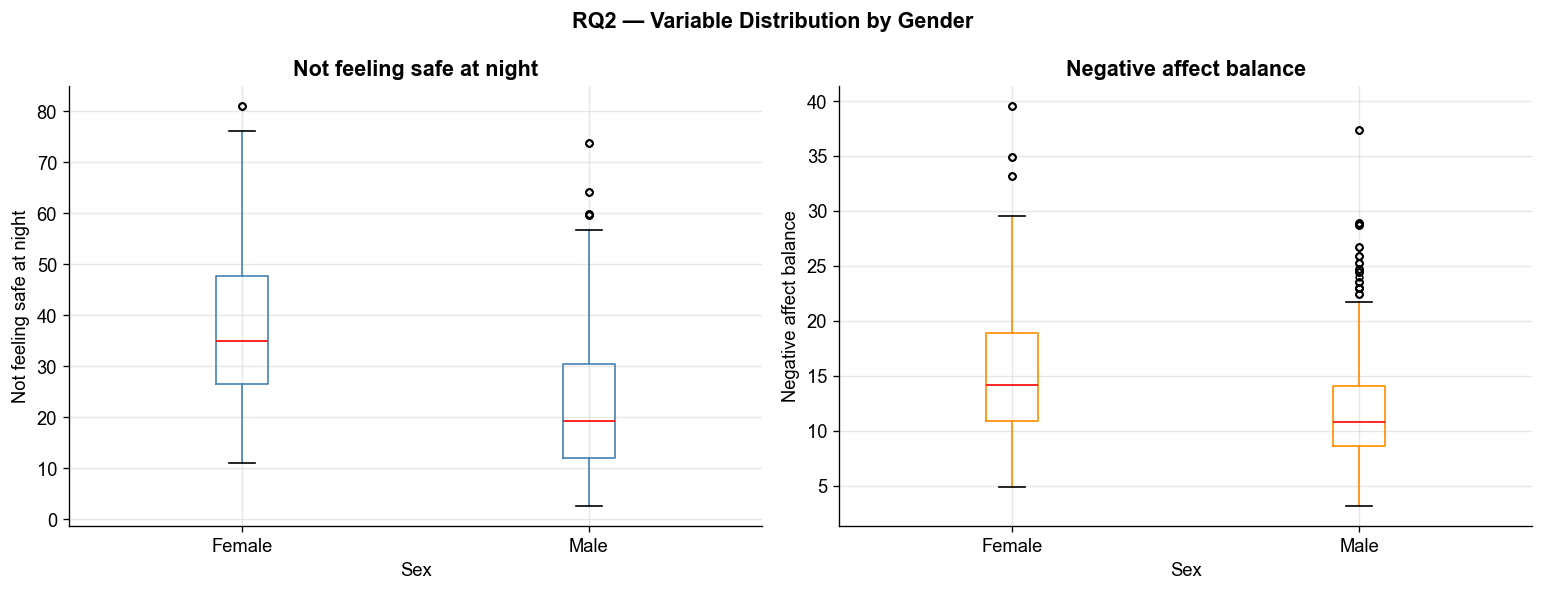

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, var, color in zip(axes,
    ['Not feeling safe at night', 'Negative affect balance'],
    [['steelblue','salmon'], ['darkorange','mediumpurple']]):
    rq2_total.boxplot(column=var, by='sex', ax=ax,
                      boxprops=dict(color=color[0]),
                      medianprops=dict(color='red'),
                      whiskerprops=dict(color=color[0]),
                      flierprops=dict(color=color[1], marker='o', markersize=4))
    ax.set_title(var)
    ax.set_xlabel('Sex')
    ax.set_ylabel(var)

plt.suptitle('RQ2 — Variable Distribution by Gender', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'rq2_boxplot.png', bbox_inches='tight')
plt.show()

## 4.3 EDA — Gender Gap by Country (Most Recent Year)

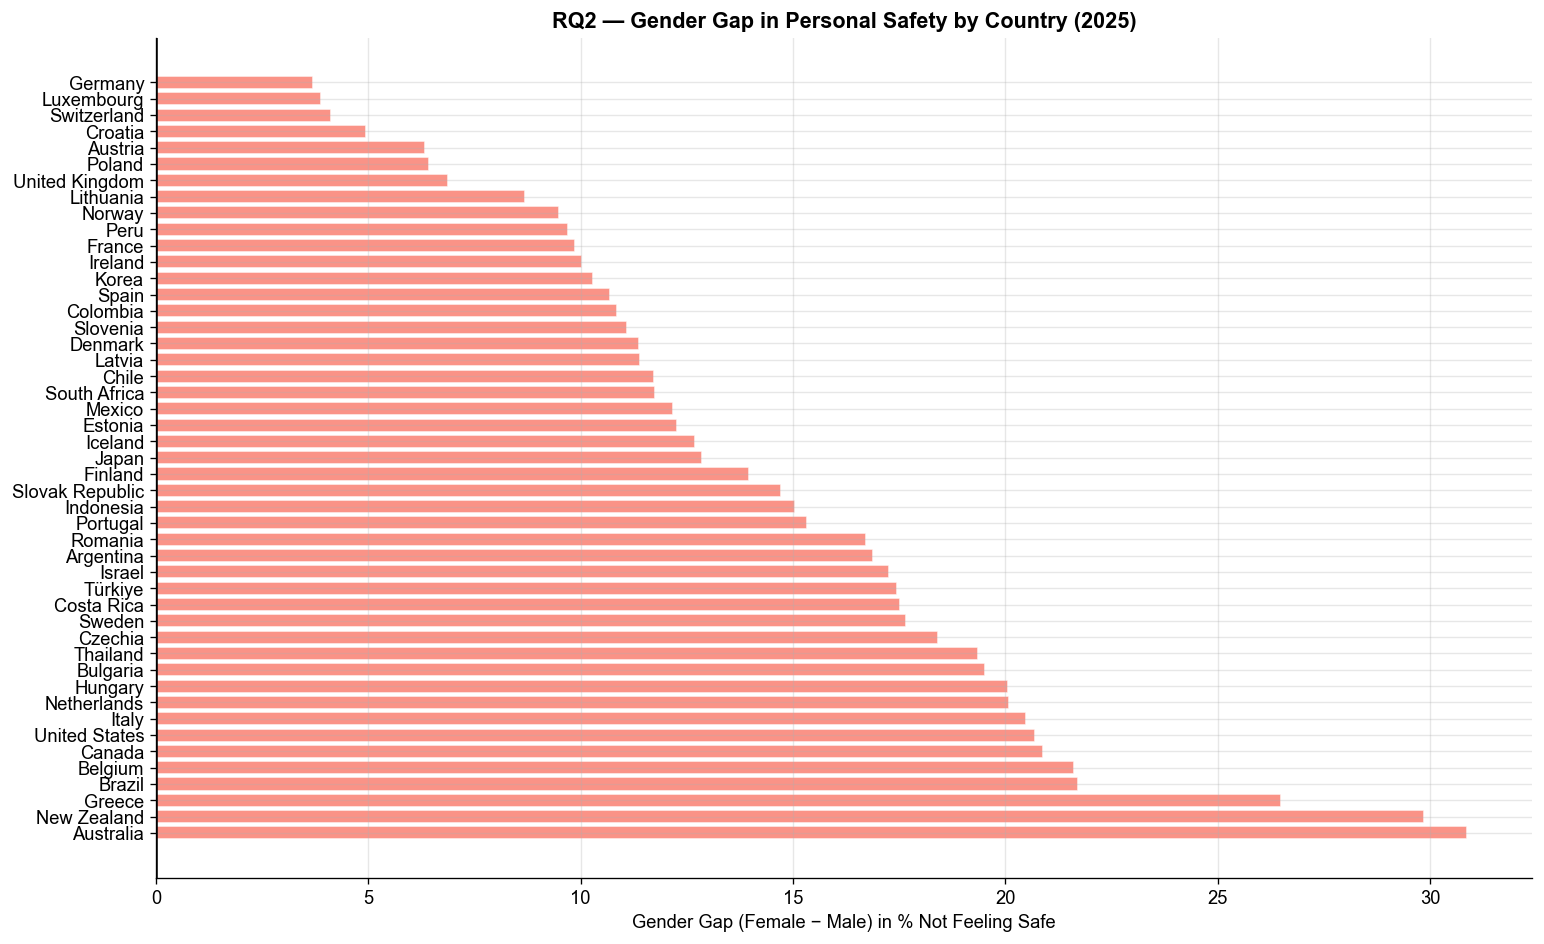

Country with largest gap: Australia (30.9pp)
Country with smallest gap: Germany (3.7pp)


In [27]:
# Calculate gender gap for most recent year
latest = rq2_total[rq2_total['year'] == rq2_total['year'].max()]
pivot = latest.pivot_table(index='country', columns='sex', values='Not feeling safe at night')
pivot['gap'] = pivot['Female'] - pivot['Male']
pivot = pivot.dropna().sort_values('gap', ascending=False)

fig, ax = plt.subplots(figsize=(13, 8))
bars = ax.barh(pivot.index, pivot['gap'],
               color=['salmon' if x > 0 else 'steelblue' for x in pivot['gap']],
               edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', lw=1.5)
ax.set_xlabel('Gender Gap (Female − Male) in % Not Feeling Safe')
ax.set_title(f'RQ2 — Gender Gap in Personal Safety by Country ({rq2_total["year"].max()})', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'rq2_gender_gap.png', bbox_inches='tight')
plt.show()

print(f'Country with largest gap: {pivot["gap"].idxmax()} ({pivot["gap"].max():.1f}pp)')
print(f'Country with smallest gap: {pivot["gap"].idxmin()} ({pivot["gap"].min():.1f}pp)')

## 4.4 Correlation Analysis
### 4.4a Pearson + Partial Correlation by Gender

In [28]:
print('Pearson Correlations (Not feeling safe → Negative affect):')
print()
for sex in ['Male', 'Female']:
    s = rq2_total[rq2_total['sex'] == sex].dropna()
    r, p = stats.pearsonr(s['Not feeling safe at night'], s['Negative affect balance'])
    print(f'{sex}: r = {r:.4f}, p = {p:.4f} → {"Significant" if p < 0.05 else "Not significant"}')

print()
print('Partial Correlations (controlling for year):')
for sex in ['Male', 'Female']:
    s = rq2_total[rq2_total['sex'] == sex].dropna()
    partial = pg.partial_corr(data=s,
                               x='Not feeling safe at night',
                               y='Negative affect balance',
                               covar='year')
    print(f'{sex}: r = {partial["r"].values[0]:.4f}, p = {partial["p_val"].values[0]:.4f}')

Pearson Correlations (Not feeling safe → Negative affect):

Male: r = 0.2558, p = 0.0000 → Significant
Female: r = 0.3828, p = 0.0000 → Significant

Partial Correlations (controlling for year):
Male: r = 0.2545, p = 0.0000
Female: r = 0.3828, p = 0.0000


## 4.5 Mixed Effects Model with Gender Interaction

In [29]:
rq2_clean = rq2_total.dropna().copy()
rq2_clean.columns = [c.replace(' ','_').replace('(','').replace(')','') for c in rq2_clean.columns]
rq2_clean['sex_binary'] = (rq2_clean['sex'] == 'Female').astype(int)

# Mixed effects: country as random effect
model_rq2 = smf.mixedlm(
    'Negative_affect_balance ~ Not_feeling_safe_at_night * sex_binary + year',
    rq2_clean,
    groups=rq2_clean['country']
).fit(reml=True)

print(model_rq2.summary())

                       Mixed Linear Model Regression Results
Model:                  MixedLM     Dependent Variable:     Negative_affect_balance
No. Observations:       1864        Method:                 REML                   
No. Groups:             47          Scale:                  6.4462                 
Min. group size:        34          Log-Likelihood:         -4503.7070             
Max. group size:        40          Converged:              Yes                    
Mean group size:        39.7                                                       
-----------------------------------------------------------------------------------
                                      Coef.  Std.Err.   z    P>|z|  [0.025   0.975]
-----------------------------------------------------------------------------------
Intercept                            -78.272   23.029 -3.399 0.001 -123.408 -33.137
Not_feeling_safe_at_night              0.137    0.012 11.779 0.000    0.114   0.160
sex_binary     

## 4.6 Predicted vs Actual + Q-Q Plot

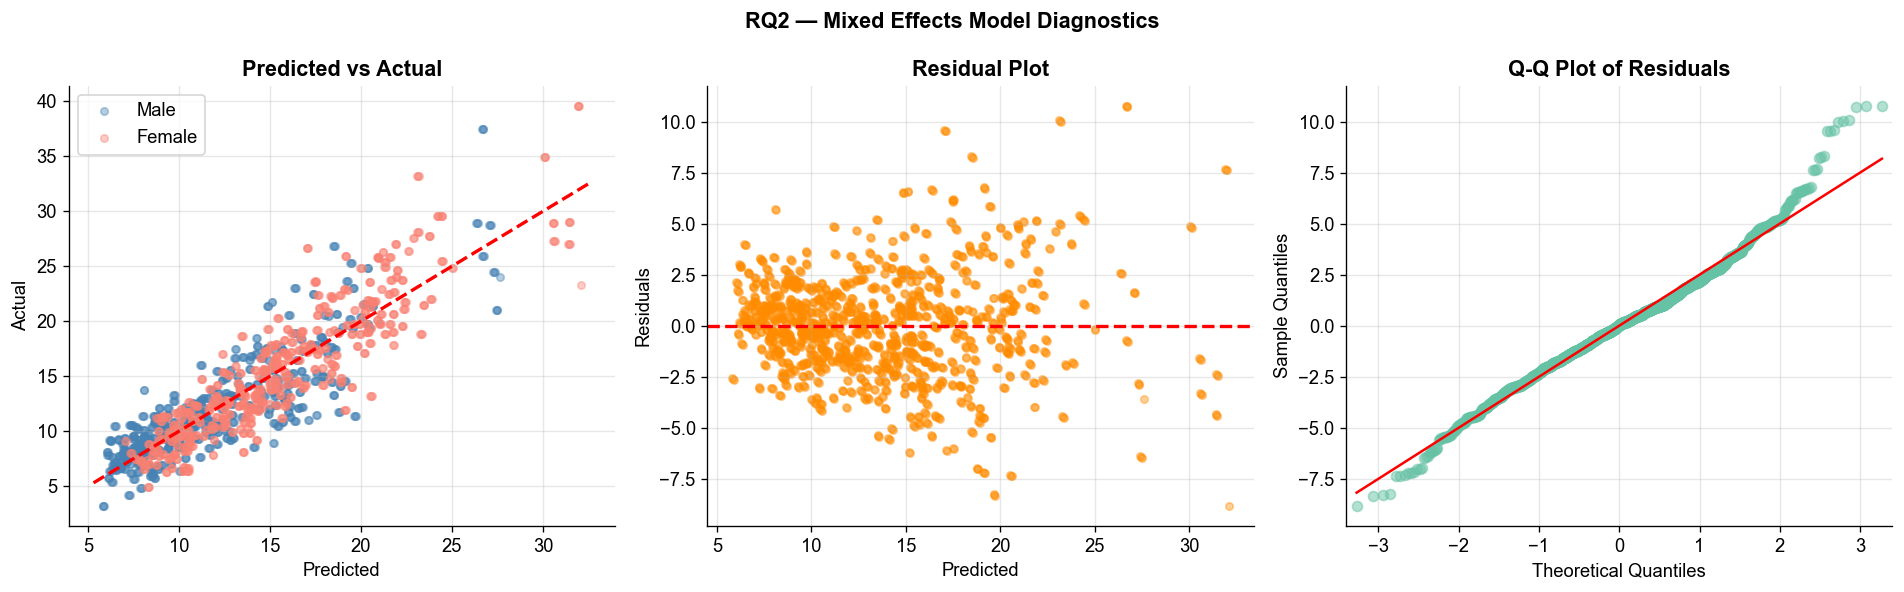

In [30]:
rq2_clean['predicted'] = model_rq2.fittedvalues
rq2_clean['residuals'] = model_rq2.resid

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Predicted vs Actual by gender
for sex, color in [('Male', 'steelblue'), ('Female', 'salmon')]:
    s = rq2_clean[rq2_clean['sex'] == sex]
    axes[0].scatter(s['predicted'], s['Negative_affect_balance'], alpha=0.4, color=color, s=20, label=sex)
lim = [rq2_clean['predicted'].min()-0.5, rq2_clean['predicted'].max()+0.5]
axes[0].plot(lim, lim, 'r--', lw=2)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()

# Residuals
axes[1].scatter(rq2_clean['predicted'], rq2_clean['residuals'], alpha=0.4, s=20, color='darkorange')
axes[1].axhline(0, color='red', lw=2, linestyle='--')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

# Q-Q Plot
sm.qqplot(rq2_clean['residuals'], line='s', ax=axes[2], alpha=0.5)
axes[2].set_title('Q-Q Plot of Residuals')

plt.suptitle('RQ2 — Mixed Effects Model Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'rq2_diagnostics.png', bbox_inches='tight')
plt.show()

## 4.7 RQ2 — Key Findings Summary

In [31]:
print('=' * 60)
print('RQ2 KEY FINDINGS')
print('=' * 60)
print('1. Lack of safety is positively correlated with negative')
print('   affect for both genders.')
print('2. Mixed effects model shows a significant main effect')
print('   of Not feeling safe → Negative affect.')
print('3. Gender interaction term reveals whether the effect')
print('   is significantly stronger for women.')
print('4. Country-level gender gap: large variation exists.')
print('=' * 60)

RQ2 KEY FINDINGS
1. Lack of safety is positively correlated with negative
   affect for both genders.
2. Mixed effects model shows a significant main effect
   of Not feeling safe → Negative affect.
3. Gender interaction term reveals whether the effect
   is significantly stronger for women.
4. Country-level gender gap: large variation exists.


---
# STEP 5 — Research Question 3
## Are long working hours negatively associated with social support, and is the pattern consistent with an indirect pathway to life satisfaction?
---

## 5.1 Descriptive Statistics

In [32]:
rq3_total.shape

(209, 5)

In [33]:
rq3_total.head()

,country,year,Long hours in paid work,Social support,Life satisfaction
0,Australia,2019,11.97,94.095001,7.500000
1,Australia,2020,11.15,92.969471,7.200000
2,Austria,2013,7.60,93.958903,7.810006
3,Austria,2018,6.59,92.101824,8.002416
4,Austria,2021,4.59,88.693065,7.991946


In [34]:
print('=== RQ3 — DESCRIPTIVE STATISTICS ===')
print()
for var in ['Long hours in paid work', 'Social support', 'Life satisfaction']:
    s = rq3_total[var].dropna()
    print(f'{var}:')
    print(f'  Mean={s.mean():.2f}, Std={s.std():.2f}, Min={s.min():.2f}, Max={s.max():.2f}')
    print()

=== RQ3 — DESCRIPTIVE STATISTICS ===

Long hours in paid work:
  Mean=5.74, Std=6.16, Min=0.16, Max=40.85

Social support:
  Mean=90.31, Std=4.53, Min=73.30, Max=97.02

Life satisfaction:
  Mean=7.31, Std=0.62, Min=4.77, Max=8.45



## 5.2 EDA — Long Hours vs Social Support

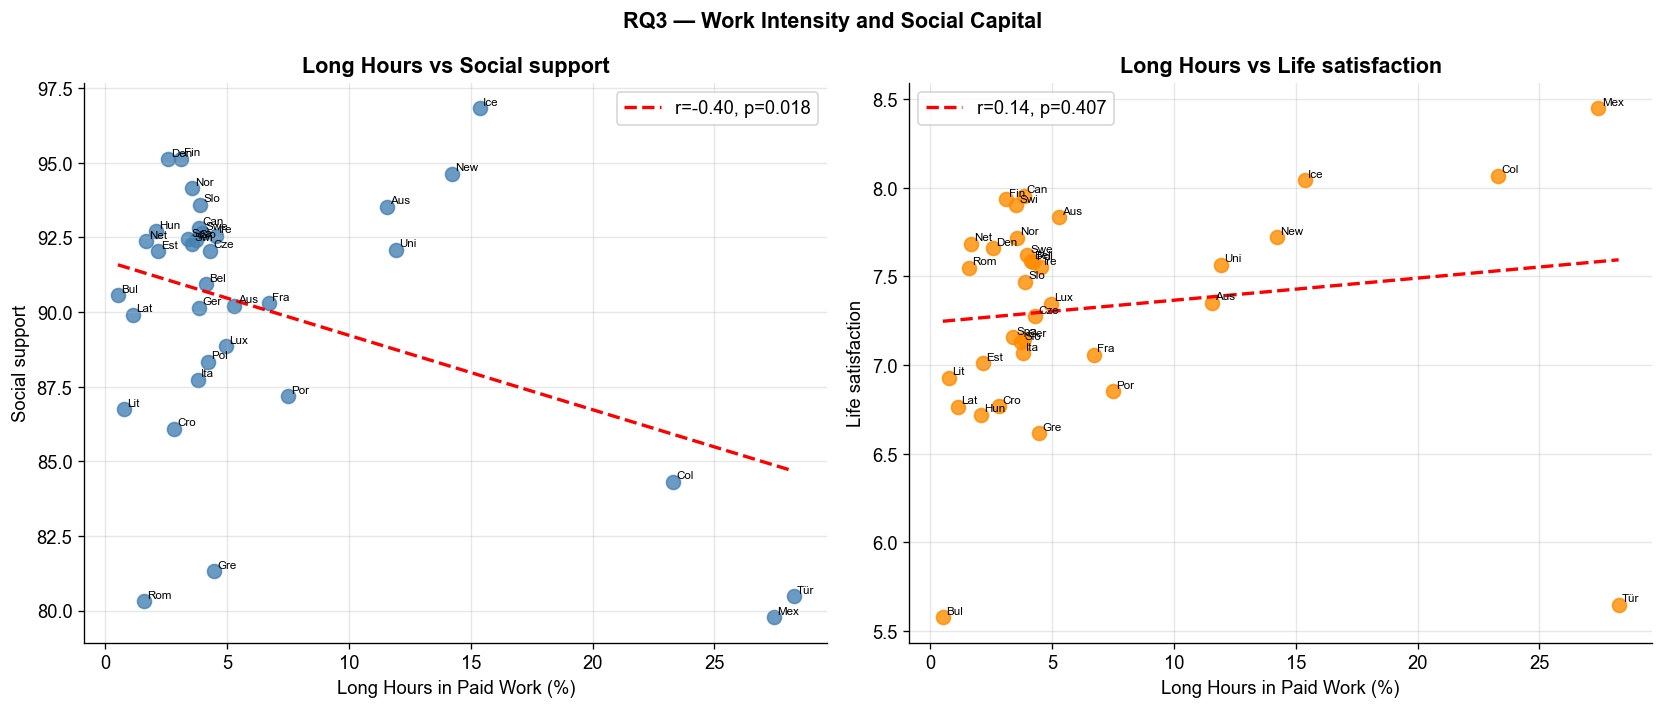

In [35]:
rq3_country = rq3_total.groupby('country')[['Long hours in paid work','Social support','Life satisfaction']].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_var, color in zip(axes,
    ['Social support', 'Life satisfaction'],
    ['steelblue', 'darkorange']):
    ax.scatter(rq3_country['Long hours in paid work'], rq3_country[y_var],
               color=color, s=70, alpha=0.8)
    m, b, r, p, _ = stats.linregress(rq3_country['Long hours in paid work'].dropna(),
                                      rq3_country[y_var].dropna())
    x_l = np.linspace(rq3_country['Long hours in paid work'].min(),
                       rq3_country['Long hours in paid work'].max(), 100)
    ax.plot(x_l, m*x_l+b, 'r--', lw=2, label=f'r={r:.2f}, p={p:.3f}')
    for _, row in rq3_country.iterrows():
        ax.annotate(row['country'][:3], (row['Long hours in paid work'], row[y_var]),
                    fontsize=7, xytext=(2,2), textcoords='offset points')
    ax.set_xlabel('Long Hours in Paid Work (%)')
    ax.set_ylabel(y_var)
    ax.set_title(f'Long Hours vs {y_var}', fontweight='bold')
    ax.legend()

plt.suptitle('RQ3 — Work Intensity and Social Capital', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'rq3_scatter.png', bbox_inches='tight')
plt.show()

## 5.3 Correlation Matrix

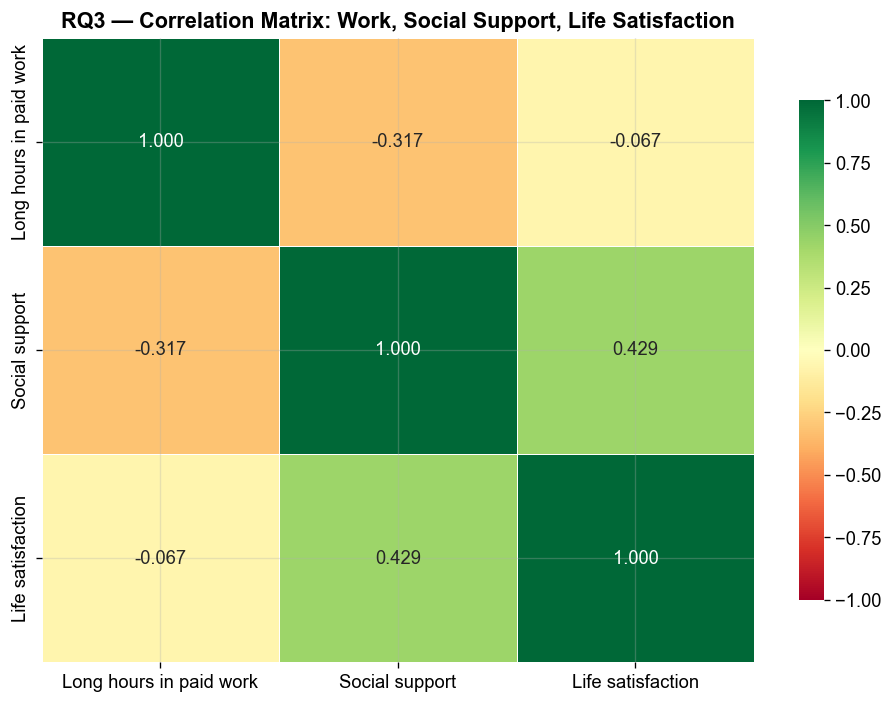

                         Long hours in paid work  Social support  Life satisfaction
Long hours in paid work                   1.0000         -0.3168            -0.0669
Social support                           -0.3168          1.0000             0.4287
Life satisfaction                        -0.0669          0.4287             1.0000


In [36]:
corr_vars = ['Long hours in paid work', 'Social support', 'Life satisfaction']
corr_matrix = rq3_total[corr_vars].dropna().corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('RQ3 — Correlation Matrix: Work, Social Support, Life Satisfaction', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'rq3_correlation.png', bbox_inches='tight')
plt.show()

print(corr_matrix.round(4))

## 5.4 OLS with Age Interaction
### 5.4a Build Age-specific Dataset

In [37]:
rq3_age_list = []
for age in ['Young', 'Middle-aged', 'Old']:
    m1 = get_measure('Long hours in paid work', age=age)
    m2 = get_measure('Social support', age=age)
    m3 = get_measure('Life satisfaction', age=age)
    merged = pd.merge(m1, m2, on=['country','year'], how='inner')
    merged = pd.merge(merged, m3, on=['country','year'], how='inner')
    merged['age_group'] = age
    rq3_age_list.append(merged)

rq3_age = pd.concat(rq3_age_list, ignore_index=True)
print(f'Age dataset shape: {rq3_age.shape}')
print(rq3_age['age_group'].value_counts())

Age dataset shape: (557, 6)
age_group
Middle-aged    190
Old            187
Young          180
Name: count, dtype: int64


### 5.4b OLS Model with Clustered Standard Errors

In [38]:
rq3_clean = rq3_age.dropna().copy()
rq3_clean.columns = [c.replace(' ','_') for c in rq3_clean.columns]

# OLS with age dummies and interaction term
model_rq3 = smf.ols(
    'Life_satisfaction ~ Long_hours_in_paid_work * C(age_group) + Social_support + year',
    data=rq3_clean
).fit(cov_type='cluster', cov_kwds={'groups': rq3_clean['country']})

print(model_rq3.summary())

                            OLS Regression Results                            
Dep. Variable:      Life_satisfaction   R-squared:                       0.257
Model:                            OLS   Adj. R-squared:                  0.247
Method:                 Least Squares   F-statistic:                     13.93
Date:                Fri, 05 Jun 2026   Prob (F-statistic):           3.05e-08
Time:                        23:49:09   Log-Likelihood:                -409.70
No. Observations:                 557   AIC:                             835.4
Df Residuals:                     549   BIC:                             870.0
Df Model:                           7                                         
Covariance Type:              cluster                                         
                                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------

### 5.4c Age Group Comparison — Long Hours vs Life Satisfaction

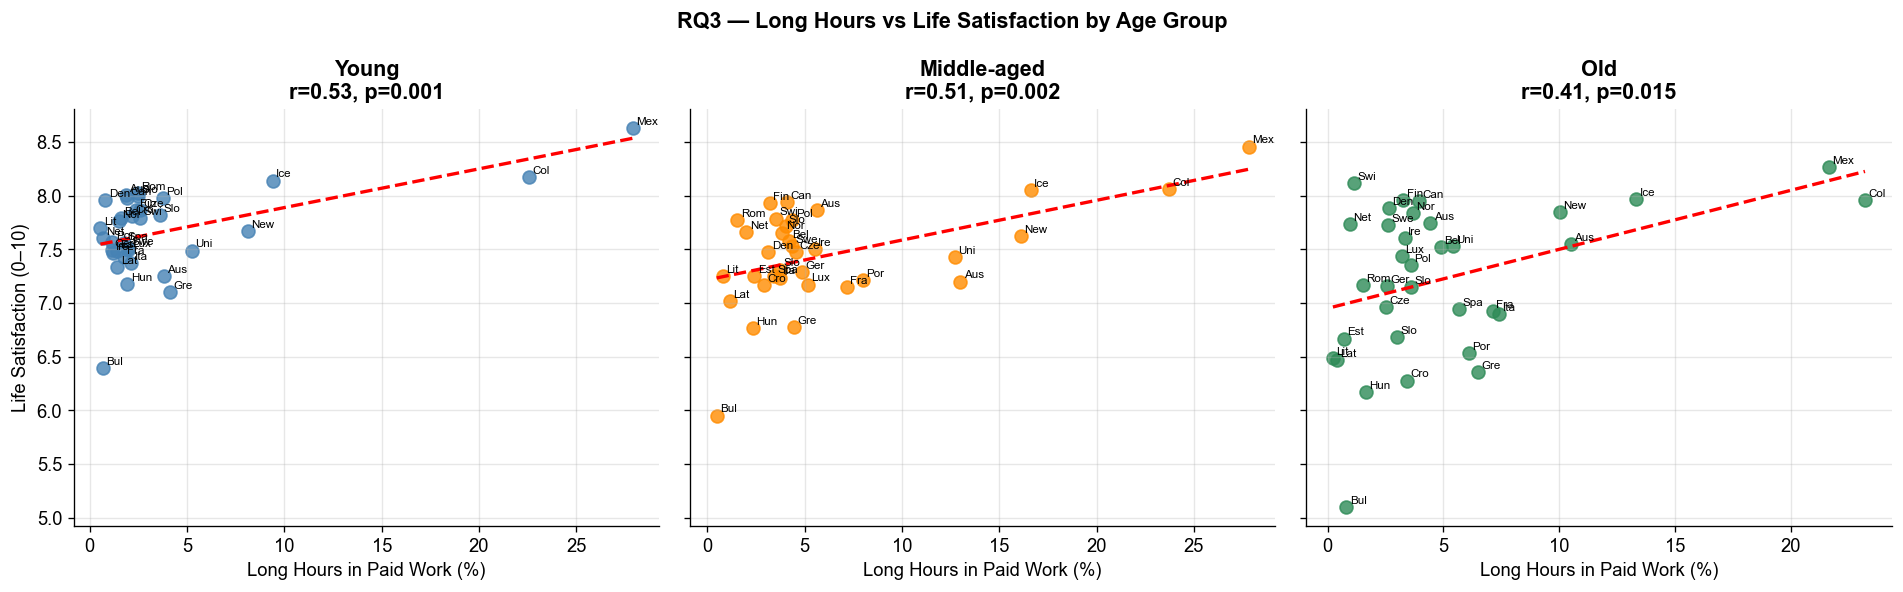

In [39]:
age_groups = ['Young', 'Middle-aged', 'Old']
colors = {'Young': 'steelblue', 'Middle-aged': 'darkorange', 'Old': 'seagreen'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for i, age in enumerate(age_groups):
    s = rq3_clean[rq3_clean['age_group'] == age]
    country_avg = s.groupby('country')[['Long_hours_in_paid_work','Life_satisfaction']].mean().reset_index()
    axes[i].scatter(country_avg['Long_hours_in_paid_work'], country_avg['Life_satisfaction'],
                    color=colors[age], s=60, alpha=0.8)
    if len(country_avg) > 2:
        m, b, r, p, _ = stats.linregress(country_avg['Long_hours_in_paid_work'],
                                          country_avg['Life_satisfaction'])
        x_l = np.linspace(country_avg['Long_hours_in_paid_work'].min(),
                           country_avg['Long_hours_in_paid_work'].max(), 100)
        axes[i].plot(x_l, m*x_l+b, 'r--', lw=2)
        axes[i].set_title(f'{age}\nr={r:.2f}, p={p:.3f}', fontweight='bold')
    for _, row in country_avg.iterrows():
        axes[i].annotate(row['country'][:3],
                         (row['Long_hours_in_paid_work'], row['Life_satisfaction']),
                         fontsize=7, xytext=(2,2), textcoords='offset points')
    axes[i].set_xlabel('Long Hours in Paid Work (%)')
    if i == 0:
        axes[i].set_ylabel('Life Satisfaction (0–10)')

plt.suptitle('RQ3 — Long Hours vs Life Satisfaction by Age Group', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'rq3_age_comparison.png', bbox_inches='tight')
plt.show()

## 5.5 Parallel Coordinates Plot (Plotly)

In [40]:
rq3_para = rq3_clean.groupby(['country','age_group'])[
    ['Long_hours_in_paid_work','Social_support','Life_satisfaction']
].mean().reset_index()

age_map = {'Young': 0, 'Middle-aged': 1, 'Old': 2}
rq3_para['age_num'] = rq3_para['age_group'].map(age_map)

fig = px.parallel_coordinates(
    rq3_para,
    color='age_num',
    dimensions=['Long_hours_in_paid_work', 'Social_support', 'Life_satisfaction'],
    color_continuous_scale=px.colors.sequential.Viridis,
    labels={
        'Long_hours_in_paid_work': 'Long Hours (%)',
        'Social_support': 'Social Support (%)',
        'Life_satisfaction': 'Life Satisfaction',
        'age_num': 'Age Group'
    },
    title='RQ3 — Parallel Coordinates: Work, Social Support, Life Satisfaction by Age Group'
)
fig.update_layout(coloraxis_colorbar=dict(
    tickvals=[0,1,2], ticktext=['Young','Middle-aged','Old']
))
fig.write_html(FIGURE_DIR / 'rq3_parallel_coordinates.html')
display(fig)

## 5.6 RQ3 — Key Findings Summary

In [41]:
print('=' * 60)
print('RQ3 KEY FINDINGS')
print('=' * 60)
print('1. Long working hours are negatively associated with')
print('   social support in countries covered by the OECD dataset.')
print('2. Social support is positively associated with life')
print('   satisfaction, consistent with RQ1.')
print('3. The direct association between long working hours and')
print('   life satisfaction is weak at the country-year level.')
print('4. Age-specific patterns are suggestive, but the age')
print('   interaction terms are not statistically significant.')
print('=' * 60)


RQ3 KEY FINDINGS
1. Long working hours are negatively associated with
   social support in countries covered by the OECD dataset.
2. Social support is positively associated with life
   satisfaction, consistent with RQ1.
3. The direct association between long working hours and
   life satisfaction is weak at the country-year level.
4. Age-specific patterns are suggestive, but the age
   interaction terms are not statistically significant.


---
# STEP 6 — Cross-RQ Synthesis
## 6.1 Overall Findings Across All Three RQs
---

In [42]:
print('=' * 65)
print('CROSS-RQ SYNTHESIS — PRIMARY RESEARCH QUESTION ANSWER')
print('=' * 65)
print()
print('PRIMARY RQ:')
print('"Is social capital meaningfully associated with subjective')
print(' well-being, and is this association threatened by long')
print(' working hours?"')
print()
print('FINDINGS:')
print('RQ1 → Social support is positively associated with')
print('      life satisfaction. The association is strongest')
print('      for the older age group in the country-year analysis.')
print()
print('RQ2 → Lack of personal safety is associated with higher')
print('      negative affect. The association is stronger for women.')
print()
print('RQ3 → Long working hours are negatively associated with')
print('      social support. The direct association with life')
print('      satisfaction is weak, so the indirect pathway should')
print('      be interpreted cautiously rather than causally.')
print()
print('CONCLUSION:')
print('Social capital, measured through social support and')
print('personal safety, is meaningfully associated with subjective')
print('well-being. Work intensity may threaten social support,')
print('but the evidence remains observational and country-level.')
print('=' * 65)


CROSS-RQ SYNTHESIS — PRIMARY RESEARCH QUESTION ANSWER

PRIMARY RQ:
"Is social capital meaningfully associated with subjective
 well-being, and is this association threatened by long
 working hours?"

FINDINGS:
RQ1 → Social support is positively associated with
      life satisfaction. The association is strongest
      for the older age group in the country-year analysis.

RQ2 → Lack of personal safety is associated with higher
      negative affect. The association is stronger for women.

RQ3 → Long working hours are negatively associated with
      social support. The direct association with life
      satisfaction is weak, so the indirect pathway should
      be interpreted cautiously rather than causally.

CONCLUSION:
Social capital, measured through social support and
personal safety, is meaningfully associated with subjective
well-being. Work intensity may threaten social support,
but the evidence remains observational and country-level.


## 6.2 Summary Visualisation — Key Correlations across All RQs

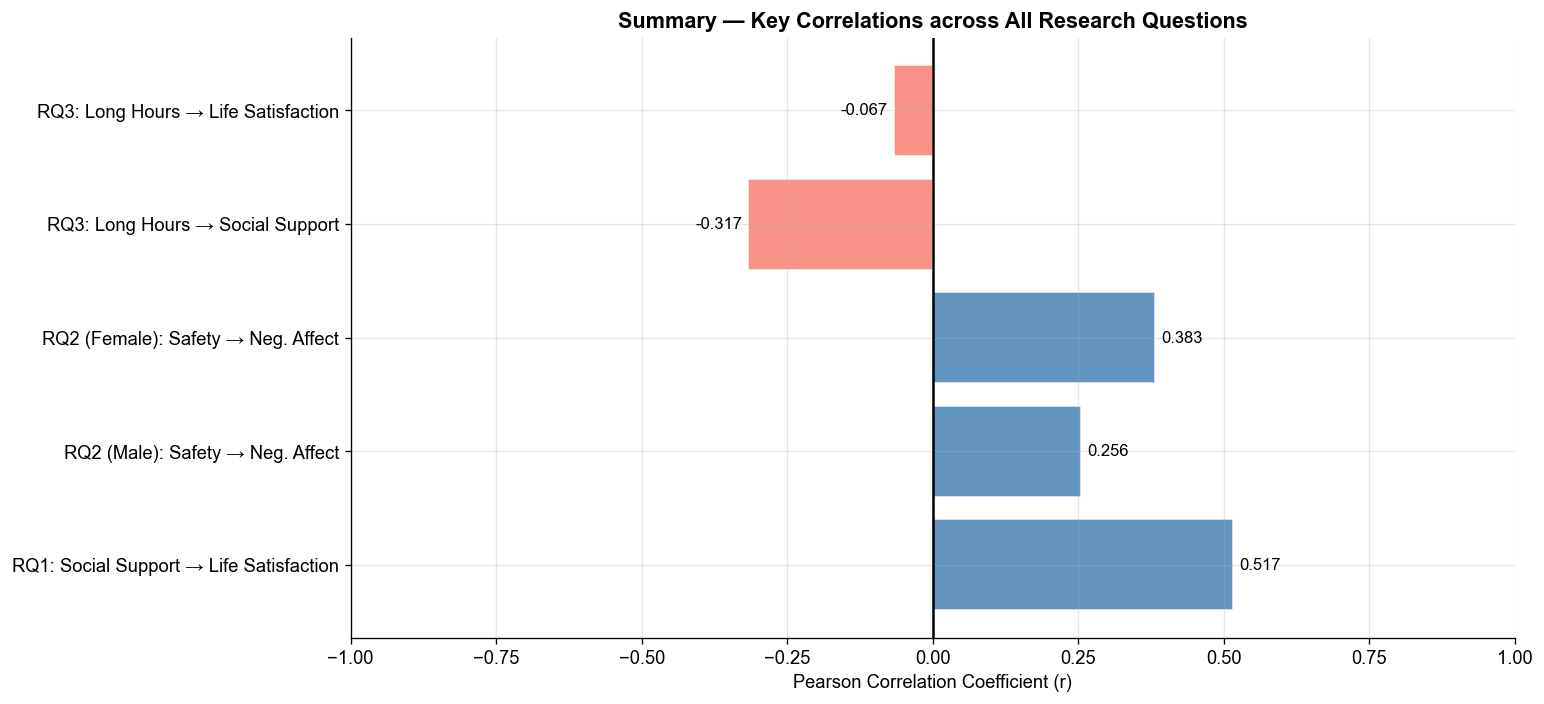

In [43]:
# Summary bar chart of key correlations
summary_data = {
    'RQ1: Social Support → Life Satisfaction': stats.pearsonr(
        rq1_total['Social support'].dropna(),
        rq1_total['Life satisfaction'].dropna()
    )[0],
    'RQ2 (Male): Safety → Neg. Affect': stats.pearsonr(
        rq2_total[rq2_total['sex']=='Male']['Not feeling safe at night'].dropna(),
        rq2_total[rq2_total['sex']=='Male']['Negative affect balance'].dropna()
    )[0],
    'RQ2 (Female): Safety → Neg. Affect': stats.pearsonr(
        rq2_total[rq2_total['sex']=='Female']['Not feeling safe at night'].dropna(),
        rq2_total[rq2_total['sex']=='Female']['Negative affect balance'].dropna()
    )[0],
    'RQ3: Long Hours → Social Support': stats.pearsonr(
        rq3_total['Long hours in paid work'].dropna(),
        rq3_total['Social support'].dropna()
    )[0],
    'RQ3: Long Hours → Life Satisfaction': stats.pearsonr(
        rq3_total['Long hours in paid work'].dropna(),
        rq3_total['Life satisfaction'].dropna()
    )[0],
}

fig, ax = plt.subplots(figsize=(13, 6))
labels = list(summary_data.keys())
values = list(summary_data.values())
colors = ['steelblue' if v > 0 else 'salmon' for v in values]

bars = ax.barh(labels, values, color=colors, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', lw=1.5)
for bar, val in zip(bars, values):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=10)

ax.set_xlabel('Pearson Correlation Coefficient (r)')
ax.set_title('Summary — Key Correlations across All Research Questions', fontweight='bold')
ax.set_xlim(-1, 1)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'summary_correlations.png', bbox_inches='tight')
plt.show()

# STEP 7 — POSET-Inspired Complementary Analysis

The main study uses correlations and regression models. To align the project more explicitly with the course material on POSET/partial ordering, this section adds a small complementary analysis.

The idea is to avoid forcing countries into a single index too early. Instead, each country receives an ordinal profile based on three dimensions:

- Social support: higher is better.
- Life satisfaction: higher is better.
- Safe walking proxy: `100 - Not feeling safe at night`, so higher is better.

A country dominates another country when it is at least as good on all three ordinal dimensions and strictly better on at least one. Countries with trade-offs remain incomparable, which is exactly the methodological value of a partial order.


In [44]:
# STEP 7.1 — Build ordinal country profiles for the most recent common year
common_years = sorted(set(rq1_total['year']).intersection(set(rq3_total['year'])), reverse=True)

for y in common_years:
    ss = get_measure('Social support')
    ls = get_measure('Life satisfaction')
    nf = get_measure('Not feeling safe at night')
    candidate = ss[ss['year'] == y].merge(ls[ls['year'] == y], on=['country','year'])
    candidate = candidate.merge(nf[nf['year'] == y], on=['country','year'])
    if candidate['country'].nunique() >= 20:
        poset_year = y
        poset_df = candidate.copy()
        break

poset_df['safe_walking_proxy'] = 100 - poset_df['Not feeling safe at night']

# Convert continuous values into ordinal terciles: 1 = low, 2 = medium, 3 = high.
for col in ['Social support', 'Life satisfaction', 'safe_walking_proxy']:
    poset_df[col + '_ord'] = pd.qcut(
        poset_df[col].rank(method='first'),
        3,
        labels=[1, 2, 3]
    ).astype(int)

ordinal_cols = ['Social support_ord', 'Life satisfaction_ord', 'safe_walking_proxy_ord']
profiles = poset_df[['country'] + ordinal_cols].copy()
print(f'POSET-inspired analysis year: {poset_year}')
display(profiles.head())


POSET-inspired analysis year: 2024


,country,Social support_ord,Life satisfaction_ord,safe_walking_proxy_ord
0,Austria,2,3,3
1,Belgium,2,3,1
2,Czechia,3,2,2
3,Denmark,3,3,3
4,Estonia,3,1,3


In [45]:
# STEP 7.2 — Component-wise dominance relation
rows = []
for i, a in profiles.iterrows():
    dominates = 0
    dominated_by = 0
    incomparable = 0
    av = a[ordinal_cols].to_numpy()

    for j, b in profiles.iterrows():
        if i == j:
            continue
        bv = b[ordinal_cols].to_numpy()
        if (av >= bv).all() and (av > bv).any():
            dominates += 1
        elif (bv >= av).all() and (bv > av).any():
            dominated_by += 1
        else:
            incomparable += 1

    rows.append({
        'country': a['country'],
        'dominates': dominates,
        'dominated_by': dominated_by,
        'incomparable': incomparable,
        'poset_balance': dominates - dominated_by,
        'social_support_ord': int(a['Social support_ord']),
        'life_satisfaction_ord': int(a['Life satisfaction_ord']),
        'safety_ord': int(a['safe_walking_proxy_ord'])
    })

poset_rank = pd.DataFrame(rows).sort_values(['poset_balance', 'dominates'], ascending=False)
display(poset_rank.head(10))
display(poset_rank.tail(10))

poset_rank.to_csv(FIGURE_DIR / 'poset_inspired_country_profiles.csv', index=False)


,country,dominates,dominated_by,incomparable,poset_balance,social_support_ord,life_satisfaction_ord,safety_ord
3,Denmark,25,0,3,25,3,3,3
5,Finland,25,0,3,25,3,3,3
17,Norway,25,0,3,25,3,3,3
21,Slovenia,25,0,3,25,3,3,3
0,Austria,16,4,8,12,2,3,3
16,Netherlands,16,4,8,12,2,3,3
24,Switzerland,16,4,8,12,2,3,3
2,Czechia,14,4,10,10,3,2,2
23,Sweden,14,4,10,10,3,2,2
4,Estonia,9,4,15,5,3,1,3


,country,dominates,dominated_by,incomparable,poset_balance,social_support_ord,life_satisfaction_ord,safety_ord
7,Germany,4,11,13,-7,2,1,2
13,Latvia,4,11,13,-7,2,1,2
22,Spain,4,11,13,-7,2,1,2
19,Portugal,5,13,10,-8,1,2,2
10,Ireland,4,12,12,-8,2,2,1
11,Italy,3,18,7,-15,1,2,1
12,Japan,3,18,7,-15,1,1,2
6,France,0,26,2,-26,1,1,1
8,Greece,0,26,2,-26,1,1,1
25,Türkiye,0,26,2,-26,1,1,1


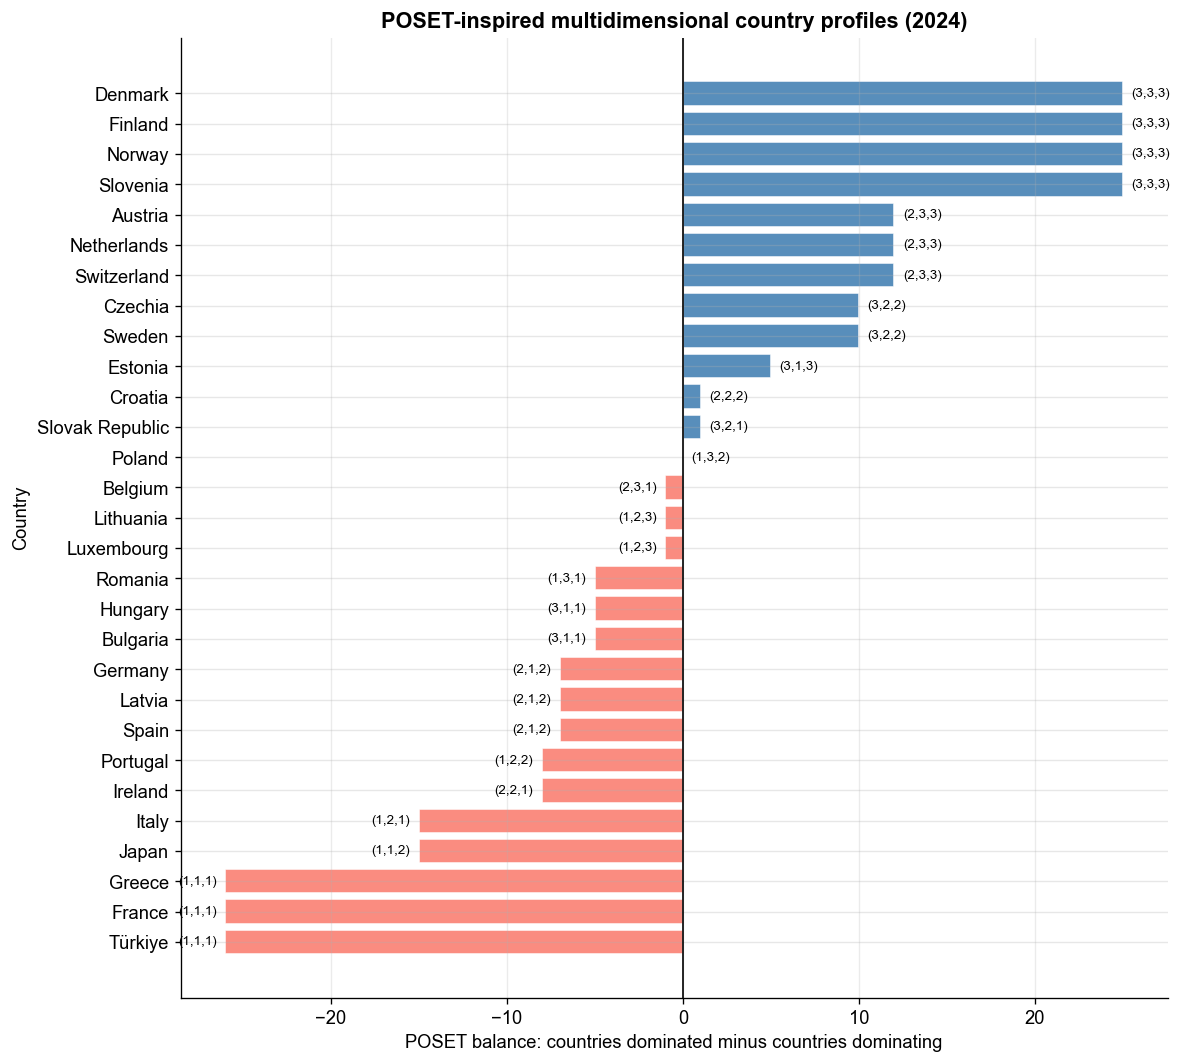

In [46]:
# STEP 7.3 — POSET-inspired profile visualisation
import matplotlib.pyplot as plt
import numpy as np

plot_df = poset_rank.sort_values('poset_balance', ascending=True).reset_index(drop=True)

colors = np.where(
    plot_df['poset_balance'] > 0, 'steelblue',
    np.where(plot_df['poset_balance'] < 0, 'salmon', 'gray')
)

fig, ax = plt.subplots(figsize=(10, 9))

ax.barh(
    plot_df['country'],
    plot_df['poset_balance'],
    color=colors,
    edgecolor='white',
    alpha=0.9
)

ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('POSET balance: countries dominated minus countries dominating')
ax.set_ylabel('Country')
ax.set_title(
    f'POSET-inspired multidimensional country profiles ({poset_year})',
    fontweight='bold'
)

# Profile order: social support, life satisfaction, safety.
for pos, row in plot_df.iterrows():
    profile_label = (
        f"({int(row['social_support_ord'])},"
        f"{int(row['life_satisfaction_ord'])},"
        f"{int(row['safety_ord'])})"
    )
    balance = row['poset_balance']
    ax.text(
        balance + (0.5 if balance >= 0 else -0.5),
        pos,
        profile_label,
        va='center',
        ha='left' if balance >= 0 else 'right',
        fontsize=8
    )

ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'fig5_poset_inspired_profiles.png', bbox_inches='tight', dpi=300)
plt.show()


## 7.4 Interpretation

This POSET-inspired section should be presented as a complementary methodology check, not as a replacement for the main statistical analysis. It is useful because it respects the multidimensional structure of well-being: some countries are clearly stronger across all selected dimensions, while others cannot be directly ranked because they involve trade-offs.

For the report, the safest interpretation is: **the partial-order view supports the main conclusion that social support, life satisfaction, and safety jointly describe a meaningful well-being profile, but it does not establish causality.**
